In [1]:
!pip install triton

In [ ]:
import torch
import triton
import triton.language as tl
DEVICE = torch.device(f'cuda:{torch.cuda.current_device()}')

#step 1:
def naive_softmax(x):
    # assume that input size is (M,N)
    x_max = x.max(dim=1) #shape (M,N)-> (M)
    # reads MN elements and writes M elements
    z = x - x_max[:,None] # shape (M,N) - shape (M,1) -> (M,N)
    # reads MN elements and writes MN elements
    numerator = torch.exp(z) # shape (M,N)
    # reads MN elements, MN flops, then writes M elements
    denominator = numerator.sum(1) # shape (M,N)-> (M)

    # reads MN+M elements, division MN flops, then writes MN elements
    output = numerator/denominator[:,None] # shape (M,N)/(M,1) = (M,N)
    return output

    # in total we did 8MN + 4M memory operations
    # our goal is to reduce this memory overhead bw DRAM and SRAM, and to try to do all of the compute with lower memory operations(as compute overhead in terms of FLOPs is faster than memory overhead)



#step 4:
@triton.jit
def _softmax_kernel(
    input_ptr, output_ptr,
    input_row_stride, output_row_stride,
    n_rows, n_cols,
    BLOCK_SIZE : tl.constexpr,
    num_stages : tl.constexpr
):

    PID = tl.program_id(0)
    row_step = tl.num_programs(0) 
    # if 4 programs, then row_step = 4
    # if n_rows = 6
    # PID 0 will get row 0
    # pid 1 will get row 1
    # pid 2 will get row 2
    # pid 3 will get row 3
    # once the pids are done with their assigned rows
    # pid 0 += row_step so it gets row 4
    # pid 1 += row_step so it gets row 5
    
    for row_idx in tl.range(PID, n_rows, row_step, num_stages = num_stages):
        row_start_ptr = input_ptr + row_idx * input_row_stride
        col_offsets = tl.arange(0, BLOCK_SIZE)
        input_ptrs = row_start_ptr + col_offsets
        mask = col_offsets < n_cols
        row = tl.load(input_ptrs, mask = mask, other = float('-inf')) # shape (BLOCK_SIZE) which is roughly shape (n_cols)
        
        #doing actual softmax:
        row_minus_max = row - tl.max(row, axis=0) # shape (BLOCK_SIZE) - (1) --> shape (BLOCK_SIZE)
        numerator = tl.exp(row_minus_max) # shape (BLOCK_SIZE)
        denominator = tl.sum(numerator, axis=0) # shape (1)
        softmax_output = numerator / denominator # shape (BLOCK_SIZE) / (1) --> shape (BLOCK_SIZE)
    
        output_row_start_ptr = output_ptr + row_idx * output_row_stride
        tl.store(output_row_start_ptr + col_offsets, softmax_output, mask = mask)



#step 3: GPU properties
properties = triton.runtime.driver.active.utils.get_device_properties(DEVICE.index)
NUM_SM = properties["multiprocessor_count"]
NUM_REGS = properties["max_num_regs"]
TOTAL_SRAM_PER_SM = properties["max_shared_mem"]
WARP_SIZE = properties.get("warpSize", properties.get("warp_size", 32))



def softmax(x):
    assert x.ndim == 2 #just for less complexity in practice
    assert x.is_contiguous() # triton works best with contiguous memory 
    n_rows, n_cols = x.shape
    BLOCK_SIZE = triton.next_power_of_2(n_cols) #power of 2 is chosen because it is efficient for parallel processing/triton works best with power of 2

    num_warps = 4 #number of warps per block
    if BLOCK_SIZE>=2048: # all these are heuristics that we could just autotune as well, but heuristics give intuition
        num_warps = 8
    if BLOCK_SIZE>=4096:
        num_warps = 16
    
    num_stages = 4 if TOTAL_SRAM_PER_SM > 200_000 else 2
    y = torch.empty_like(x)

    # kernel =  _softmax_kernel.warmup(
    #     x,y,
    #     x.stride(0), y.stride(0),
    #     n_rows, n_cols,
    #     BLOCK_SIZE = BLOCK_SIZE,
    #     num_stages = num_stages,
    #     num_warps = num_warps,
    #     grid = (1,)
    # )
    # kernel.init_handles()
    # n_regs_per_program = kernel.n_regs
    # sram_needed_per_program = kernel.metadata.shared

    # reg_occupancy = NUM_REGS// (n_regs_per_program * WARP_SIZE * num_warps) # number of programs that can run in parallel on one SM
    # sram_occupancy = TOTAL_SRAM_PER_SM // sram_needed_per_program # number of programs that can run in parallel on one SM
    
    # programs_per_sm = min(reg_occupancy, sram_occupancy) # one of them is the bottleneck, so we take the minimum of the two
    
    # num_programs = min(NUM_SM * programs_per_sm, n_rows) # n_rows because we dont wanna spin up the entire GPU if we have less rows  
    
    # grid = (num_programs, 1, 1)

    # kernel[grid](
    #     x, y,
    #     x.stride(0), y.stride(0),
    #     n_rows, n_cols
    # )
    # return y
    # # x is shape (M,N) --> x.stride() = (N,1) --> x.stride(0) = N, x.stride(1) = 1
    # # stride just tells the compiler how many bytes to skip to get to the next element in that dimension
    # # so we pass these values to the kernel


    num_programs = n_rows
    grid = (num_programs,)

    _softmax_kernel[grid](
        x, y,
        x.stride(0), y.stride(0),
        n_rows, n_cols,
        BLOCK_SIZE=BLOCK_SIZE,
        num_stages=num_stages,
        num_warps=num_warps,
    )
    return y



#step 2:
def test_softmax_kernel(size : tuple, atol=1e-3, rtol=1e-3, device=DEVICE):
    assert type(size) is tuple and len(size) == 2
    torch.manual_seed(0)
    x = torch.randn(size[0], size[1], device=DEVICE)
    z_tri = softmax(x)
    z_torch = torch.softmax(x, axis=1)
    torch.testing.assert_close(z_tri, z_torch, atol=atol, rtol=rtol)
    print("Softmax kernel passed")


#step 5 : benchmarking
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"],
        x_vals = [128*i for i in range(2,100)],
        line_arg = 'provider',
        line_vals = ['triton', 'torch'],
        line_names = ['Triton', 'Torch'],
        styles = [('blue', '-'), ('orange', '--')],
        ylabel = 'GB/s',
        plot_name = 'softmax-performance',
        args = {'M':4096}
    )
)
def softmax_benchmark(M, N, provider):
    x = torch.randn(M, N, device=DEVICE, dtype = torch.float32)
    if provider == 'triton':
        ms = triton.testing.do_bench(lambda : softmax(x ))
    if provider == 'torch':
        ms = triton.testing.do_bench(lambda : torch.softmax(x, axis=-1))
    
    gbps = lambda ms : 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms)



if __name__ == "__main__":
    test_softmax_kernel((1024, 1024))

    import sys
    if len(sys.argv) > 1 and sys.argv[1] == '--benchmark':
        softmax_benchmark.run(save_path= '.', print_data =False)

Softmax kernel passed


softmax-performance:
          N  Triton (GB/s)  Torch (GB/s)
0     256.0     152.525266    206.242378
1     384.0     228.356618    219.495789
2     512.0     223.500486    216.377492
3     640.0     224.292509    212.741230
4     768.0     224.664793    213.803412
5     896.0     226.769621    211.890874
6    1024.0     227.235666    212.578297
7    1152.0     229.762769    215.091010
8    1280.0     230.169696    215.782777
9    1408.0     229.574199    213.099828
10   1536.0     230.236990    212.954073
11   1664.0     229.238468    211.123556
12   1792.0     230.046421    212.004676
13   1920.0     229.600627    210.287841
14   2048.0     230.021058    212.102288
15   2176.0     235.152698    224.434033
16   2304.0     234.841619    230.921699
17   2432.0     234.221576    234.342806
18   2560.0     233.463380    238.810413
19   2688.0     233.690892    240.905489
20   2816.0     233.534676    241.700217
21   2944.0     233.683051    242.061755
22   3072.0     233.554298    242.48

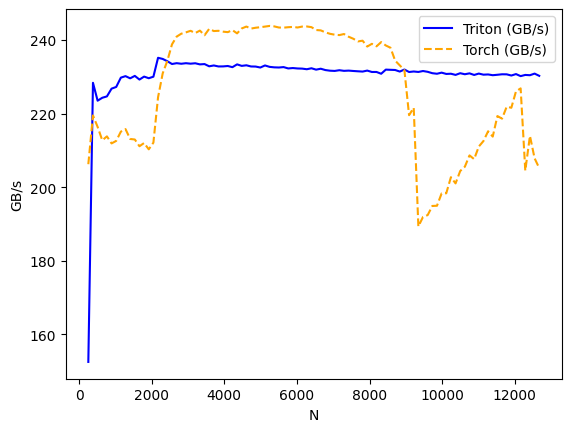

In [24]:
softmax_benchmark.run(save_path= ".", print_data =True)